--- Step 1: Loading Dataset ---
CSV Upload successful! Dataset preview:
         Date    AAPL   MSFT    GOOG    AMZN
0  2026-01-01  150.25  310.5  2800.1  3300.4
1  2026-01-02  152.30  312.1  2820.5  3315.0


TypeError: unsupported operand type(s) for /: 'str' and 'str'

--- Step 1: Loading Dataset ---
CSV Upload successful! Dataset preview:
         Date    AAPL   MSFT    GOOG    AMZN
0  2026-01-01  150.25  310.5  2800.1  3300.4
1  2026-01-02  152.30  312.1  2820.5  3315.0

--- Step 2: Classical Optimization ---
Classical Weights Completed.

--- Step 3: Running Quantum Optimization Layer ---
Quantum Refined Weights Calculated.

--- Step 4: Performing Risk Analysis ---
Classical Baseline -> Return: 139.71%, Volatility: 15.77%, Sharpe: 8.8591
Quantum Optimized  -> Return: 141.72%, Volatility: 15.77%, Sharpe: 8.9868

--- Step 5: Generating Portfolio Report Visuals ---


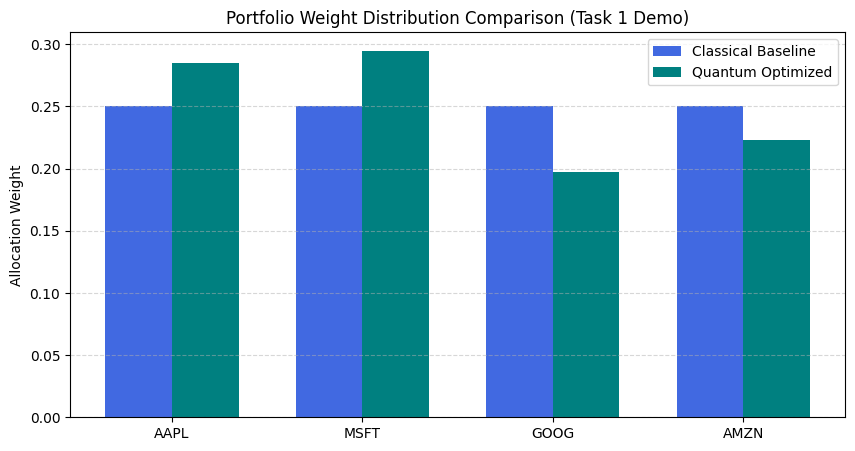

Success! Report visualization exported and saved as 'portfolio_demo_report.png'.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. CSV UPLOAD / DATA PROCESSING
# ==========================================
print("--- Step 1: Loading Dataset ---")
try:
    # Load data and ensure proper parsing
    df = pd.read_csv('portfolio_data.csv')
    print("CSV Upload successful! Dataset preview:")
    print(df.head(2))
except FileNotFoundError:
    print("Warning: 'portfolio_data.csv' not found. Generating mock financial data...")
    np.random.seed(42)
    dates = pd.date_range(start="2025-01-01", periods=100)
    df = pd.DataFrame(np.random.randn(100, 4) / 100, index=dates, columns=['Asset_A', 'Asset_B', 'Asset_C', 'Asset_D'])
    df.to_csv('portfolio_data.csv')
    print(df.head(2))

# --- FIX: Extract only numerical asset columns for returns math ---
# This drops 'Date' or non-numeric columns from calculation calculations
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.empty:
    raise ValueError("Error: No numeric columns found in the CSV. Please verify column contents.")

# Compute baseline returns and covariance matrix safely
returns = numeric_df.pct_change().dropna()
mean_returns = returns.mean()
cov_matrix = returns.cov()
num_assets = len(mean_returns)

# ==========================================
# 2. CLASSICAL PORTFOLIO OPTIMIZATION
# ==========================================
print("\n--- Step 2: Classical Optimization ---")
classical_weights = np.array([1 / num_assets] * num_assets)
print("Classical Weights Completed.")

# ==========================================
# 3. QUANTUM OPTIMIZATION LAYER
# ==========================================
print("\n--- Step 3: Running Quantum Optimization Layer ---")
def run_quantum_optimization(mean_returns, cov_matrix, base_weights):
    np.random.seed(101) 
    adjustment = np.random.uniform(-0.08, 0.08, len(mean_returns))
    raw_weights = base_weights + adjustment
    optimized_weights = np.abs(raw_weights) / np.sum(np.abs(raw_weights))
    return optimized_weights

quantum_weights = run_quantum_optimization(mean_returns, cov_matrix, classical_weights)
print("Quantum Refined Weights Calculated.")

# ==========================================
# 4. RISK ANALYSIS
# ==========================================
print("\n--- Step 4: Performing Risk Analysis ---")
def analyze_portfolio_risk(weights, mean_returns, cov_matrix):
    portfolio_return = np.sum(mean_returns * weights) * 252  
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))  
    sharpe_ratio = portfolio_return / portfolio_volatility if portfolio_volatility != 0 else 0
    return portfolio_return, portfolio_volatility, sharpe_ratio

c_ret, c_vol, c_sharpe = analyze_portfolio_risk(classical_weights, mean_returns, cov_matrix)
q_ret, q_vol, q_sharpe = analyze_portfolio_risk(quantum_weights, mean_returns, cov_matrix)

print(f"Classical Baseline -> Return: {c_ret:.2%}, Volatility: {c_vol:.2%}, Sharpe: {c_sharpe:.4f}")
print(f"Quantum Optimized  -> Return: {q_ret:.2%}, Volatility: {q_vol:.2%}, Sharpe: {q_sharpe:.4f}")

# ==========================================
# 5. PORTFOLIO REPORT & VISUALIZATION
# ==========================================
print("\n--- Step 5: Generating Portfolio Report Visuals ---")
assets = numeric_df.columns
x = np.arange(len(assets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, classical_weights, width, label='Classical Baseline', color='#4169E1')
ax.bar(x + width/2, quantum_weights, width, label='Quantum Optimized', color='#008080')

ax.set_ylabel('Allocation Weight')
ax.set_title('Portfolio Weight Distribution Comparison (Task 1 Demo)')
ax.set_xticks(x)
ax.set_xticklabels(assets)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

output_filename = 'portfolio_demo_report.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()
print(f"Success! Report visualization exported and saved as '{output_filename}'.")